In [1]:
import wandb
from ann.neural_network import *
from tensorflow.keras import datasets

2026-03-02 14:24:19.099792: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-02 14:24:19.136970: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-02 14:24:20.573611: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
(x_train,y_train),(x_test,y_test) = datasets.mnist.load_data()

In [3]:
model = NeuralNetwork.load(path= "models/best_model_final.npz")

In [52]:
run = wandb.init(
    entity="DA6401_assignment01",
    project="assignment_01",
    id="confused"
    )

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


In [5]:
from utils.data_loader import Dataloader

test_dataloader = Dataloader(x_test,y_test,one_hot=False,shuffle=False)
y_true = []
y_pred = []
logits = []
for x,y in test_dataloader:
    y_logit = model.forward(x)
    y_p = np.argmax(y_logit,axis=1)
    logits.append(y_logit)
    y_true.append(y)
    y_pred.append(y_p)

In [6]:
logits = np.concat(logits)

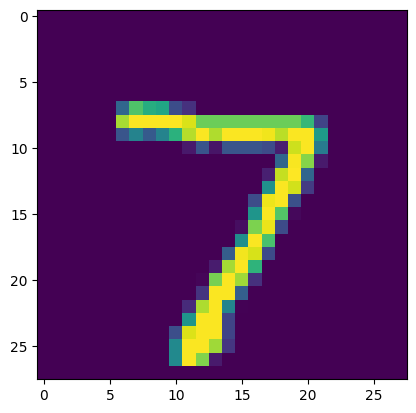

In [7]:
import matplotlib.pyplot as plt

plt.imshow(x_test[0])

In [8]:
y_pred[0]

array([7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4, 9, 6,
       6, 5, 4, 0, 7, 4, 0, 1, 3, 1])

In [9]:
y_true[0]

array([7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4, 9, 6,
       6, 5, 4, 0, 7, 4, 0, 1, 3, 1], dtype=uint8)

In [10]:
y_pred = np.hstack(y_pred)
y_true = np.hstack(y_true)

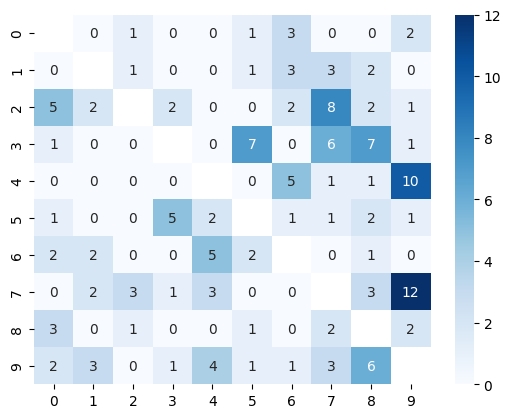

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(y_true, y_pred)


fig, ax = plt.subplots()
sns.heatmap(cm, annot=True, ax=ax,cmap="Blues", mask=np.array([[True if i==j else False for i in range(10)] for j in range(10)]))

fig.savefig('Confusion_matrix.png', transparent=True, dpi=800)

In [14]:
image = wandb.Image(plt.imread('Confusion_matrix.png'))

run.log({"Confusion_matrix": image})

In [15]:
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
top_confusions = np.argsort(cm_no_diag.flatten())[::-1][:5]

In [16]:
top_confusions

array([79, 49, 27, 38, 35])

In [66]:
true = 3; pred = 8
indices = (y_true==true) * (y_pred==pred)
indices = np.arange(10000)[indices]

In [67]:
srt_idxs = sorted(indices, key=lambda i : (logits[i,pred]), reverse=True)

In [68]:
probabs = logits[srt_idxs,pred]

In [69]:
for j,i in enumerate(srt_idxs):
    img = wandb.Image(x_test[i],caption=f'probability = {logits[i,pred]}')
    wandb.log({
        f'Confused {true} as {pred}': img, 
        'rank' : j
    })

In [39]:
y_test[indices[2]]

np.uint8(7)